In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'tensorflow_datasets'

In [ ]:
dataset, info = tfds.load(
    'cassava',
    with_info=True,
    as_supervised=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cassava/incomplete.DL1A6W_0.1.0/cassava-test.tfrecord*...:   0%|          …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cassava/incomplete.DL1A6W_0.1.0/cassava-validation.tfrecord*...:   0%|    …

Dataset cassava downloaded and prepared to /root/tensorflow_datasets/cassava/0.1.0. Subsequent calls will reuse this data.


In [ ]:
def preprocess(image, label):
    image = tf.image.resize(image, (150,150))
    image = image / 255.0
    label = tf.where(label == 0, 0, 1)
    return image, label

In [ ]:
train_size = int(0.8 * len(list(dataset['train'])))

train_data = dataset['train'].take(train_size)
val_data = dataset['train'].skip(train_size)

train_data = train_data.map(preprocess).batch(32)
val_data = val_data.map(preprocess).batch(32)

In [ ]:
data = dataset['train'].map(preprocess)

In [ ]:
data = data.shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)

In [ ]:
import matplotlib.pyplot as plt

healthy_imgs = []
diseased_imgs = []

# Separate images by class
for image, label in dataset['train'].take(2000):
    if label.numpy() == 0 and len(healthy_imgs) < 4:
        healthy_imgs.append(image)
    elif label.numpy() == 1 and len(diseased_imgs) < 4:
        diseased_imgs.append(image)

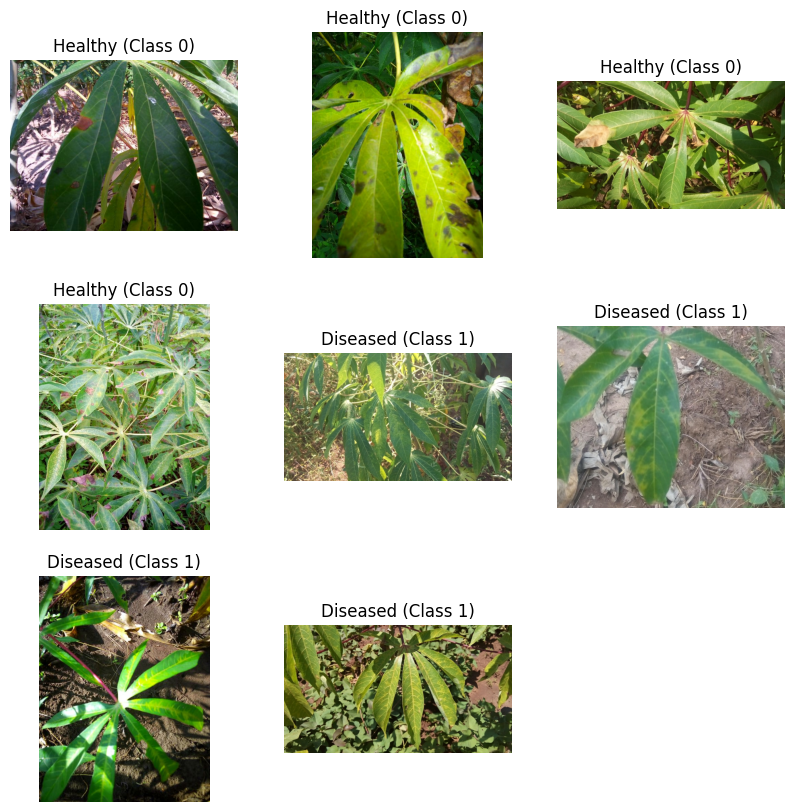

In [ ]:
# Plot 4 Healthy + 4 Diseased
plt.figure(figsize=(10,10))

for i in range(4):
    plt.subplot(3,3,i+1)
    plt.imshow(healthy_imgs[i])
    plt.title("Healthy (Class 0)")
    plt.axis("off")

for i in range(4):
    plt.subplot(3,3,i+5)
    plt.imshow(diseased_imgs[i])
    plt.title("Diseased (Class 1)")
    plt.axis("off")


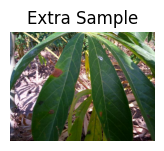

In [ ]:
# 9th image (optional extra sample)
plt.subplot(3,3,9)
plt.imshow(healthy_imgs[0])
plt.title("Extra Sample")
plt.axis("off")

plt.show()

Healthy: 407
Diseased: 4593


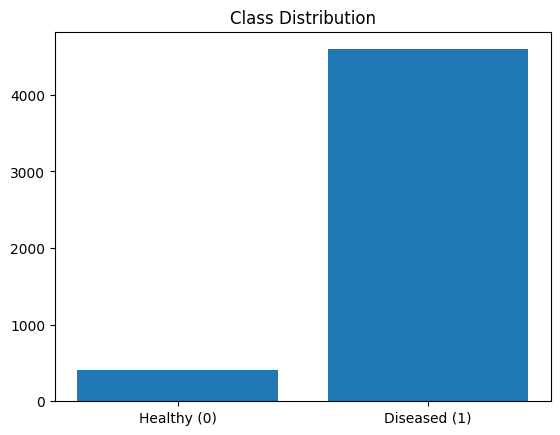

In [ ]:
import matplotlib.pyplot as plt

healthy = 0
diseased = 0

for _, label in dataset['train'].take(5000):
    if label.numpy() == 0:
        healthy += 1
    else:
        diseased += 1

print("Healthy:", healthy)
print("Diseased:", diseased)

plt.bar(['Healthy (0)', 'Diseased (1)'], [healthy, diseased])
plt.title("Class Distribution")
plt.show()

Dataset shows imbalanced distribution depending on counts.

Image Size Variance (Min, Max, Avg Width/Height)

In [ ]:
import numpy as np

widths = []
heights = []

for image, _ in dataset['train'].take(500):
    h, w = image.shape[0], image.shape[1]
    heights.append(h)
    widths.append(w)

print("Min Width:", min(widths))
print("Max Width:", max(widths))
print("Avg Width:", np.mean(widths))

print("Min Height:", min(heights))
print("Max Height:", max(heights))
print("Avg Height:", np.mean(heights))

Min Width: 499
Max Width: 1185
Avg Width: 618.498
Min Height: 500
Max Height: 942
Avg Height: 573.39


The images in the Cassava dataset show noticeable variation in dimensions. The width ranges from 499 pixels to 1185 pixels, while the height ranges from 500 pixels to 942 pixels. The average width and height are approximately 618.5 pixels and 573.4 pixels, respectively.

This variation indicates that the dataset contains non-uniform image sizes, which is common in real-world agricultural datasets. Therefore, all images were resized to 150 × 150 pixels during preprocessing to ensure consistency and improve the performance of the CNN model

Model Building
CNN MODEL (FROM SCRATCH)

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 34s 210ms/step - accuracy: 0.9138 - loss: 0.2885 - val_accuracy: 0.9099 - val_loss: 0.2817
Epoch 2/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 40s 225ms/step - accuracy: 0.9189 - loss: 0.2661 - val_accuracy: 0.9125 - val_loss: 0.2642
Epoch 3/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 24s 170ms/step - accuracy: 0.9202 - loss: 0.2553 - val_accuracy: 0.9125 - val_loss: 0.2510
Epoch 4/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 43s 184ms/step - accuracy: 0.9191 - loss: 0.2504 - val_accuracy: 0.9152 - val_loss: 0.2448
Epoch 5/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 23s 164ms/step - accuracy: 0.9198 - loss: 0.2454 - val_accuracy: 0.9125 - val_loss: 0.2321
Epoch 6/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 23s 160ms/step - accuracy: 0.9213 - loss: 0.2381 - val_accuracy: 0.9134 - val_loss: 0.2477
Epoch 7/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 32s 226ms/step - accuracy: 0.9220 - loss: 0.2287 - val_accuracy: 0.9117 - val_loss: 0.2416
Epoch 8/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 33s 168ms/step - accuracy: 0.9240 - loss: 0

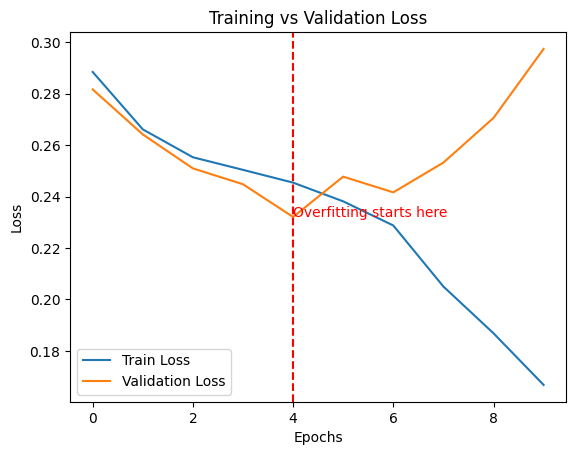

In [ ]:
import matplotlib.pyplot as plt

train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')

overfit_epoch = val_loss.index(min(val_loss))

plt.axvline(x=overfit_epoch, color='red', linestyle='--')
plt.text(overfit_epoch, val_loss[overfit_epoch],
         'Overfitting starts here', color='red')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
model.evaluate(val_data)

36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step - accuracy: 0.9099 - loss: 0.2974


[0.2974105775356293, 0.9098939895629883]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


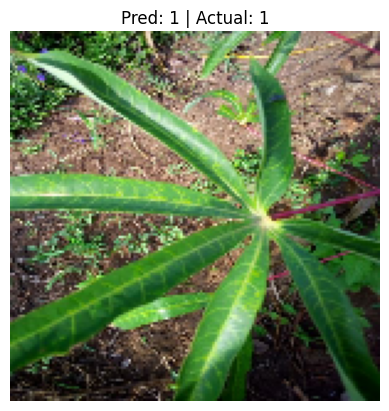

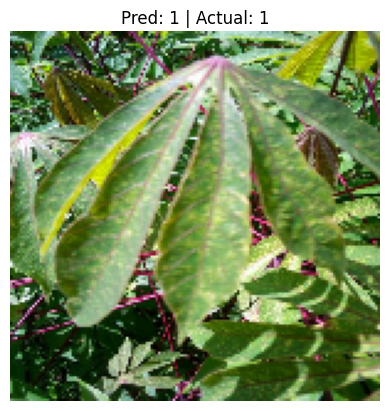

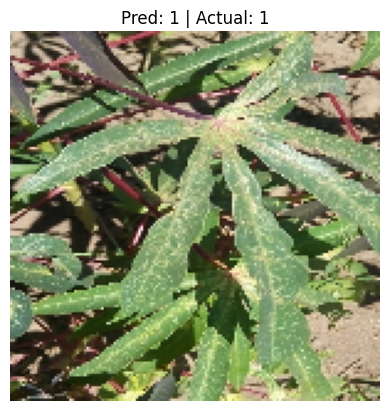

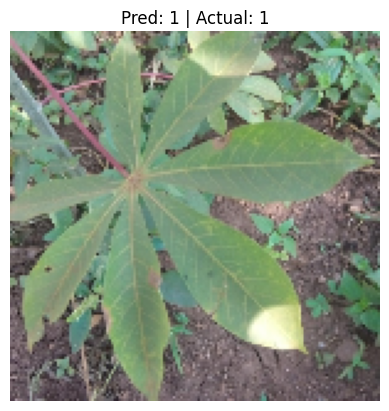

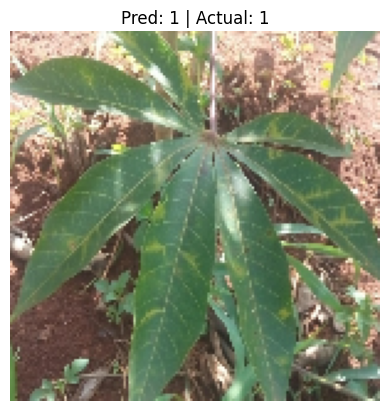

In [ ]:
for image, label in val_data.take(1):
    pred = model.predict(image)

    for i in range(5):
        plt.imshow(image[i])
        plt.title(f"Pred: {int(pred[i][0]>0.5)} | Actual: {label[i].numpy()}")
        plt.axis("off")
        plt.show()

The model misclassified some cassava leaf images due to similar texture patterns between healthy and diseased leaves. In some cases, lighting variation and background noise affected prediction accuracy. For example, a diseased leaf was classified as healthy due to subtle symptom visibility.

Final Documentation

This project implements a CNN-based binary classification model using TensorFlow to detect healthy and diseased cassava leaves. The model achieved a validation accuracy of 0.90%. The main challenge was distinguishing visually similar leaf patterns, which was addressed using deeper convolution layers and dropout.

[ Input Image 150×150×3 ]

            ↓
[ Conv2D 32 filters ]

            ↓
[ MaxPooling ]

            ↓
[ Conv2D 64 filters ]

            ↓
[ MaxPooling ]

            ↓
[ Conv2D 128 filters ]

            ↓
[ MaxPooling ]

            ↓
[ Flatten ]

            ↓
[ Dense 128 ]

            ↓
[ Dropout 0.5 ]

            ↓
[ Output: Sigmoid ]
